# Preparación de los datos

Para poder trabajar con los datos iniciales, es necesario ir a la carpeta de Archivos (al costado), arrastrar el CSV allí (no dentro de una carpeta, sino allí mismo, debajo de sample_data), y ejecutar el código.

In [20]:
# Importación de librerías que no son de Sklearn
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Importación de librerías de Sklearn
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

warnings.filterwarnings('ignore') # Ignoramos las advertencias que vaya a dar el servidor de Colab

# Importación del DataFrame
telecom = pd.read_csv('/content/datos_tratados.csv')
telecom.head()

,ID,Cancelación (churn),Género,Jubilado (+60 años),Con pareja,Dependientes,Antigüedad (meses),Servicio telefónico,Servicio de internet,Seguridad en línea,...,Protección de dispositivos,Soporte técnico,Streaming TV,Streaming de películas,Tipo de contrato,Factura electrónica,Método de pago,Cuentas mensuales,Cobro total,Cuentas diarias
0,0002-ORFBO,False,Femenino,False,True,True,9,Una línea,DSL,False,...,False,True,True,False,Un año,True,Cheque enviado por correo,65.6,593.30,2.19
1,0003-MKNFE,False,Masculino,False,False,False,9,Múltiples líneas,DSL,False,...,False,False,False,True,Mes a mes,False,Cheque enviado por correo,59.9,542.40,2.00
2,0004-TLHLJ,True,Masculino,False,False,False,4,Una línea,Fibra óptica,False,...,True,False,False,False,Mes a mes,True,Cheque electrónico,73.9,280.85,2.46
3,0011-IGKFF,True,Masculino,True,True,False,13,Una línea,Fibra óptica,False,...,True,False,True,True,Mes a mes,True,Cheque electrónico,98.0,1237.85,3.27
4,0013-EXCHZ,True,Femenino,True,True,False,3,Una línea,Fibra óptica,False,...,False,True,True,False,Mes a mes,True,Cheque enviado por correo,83.9,267.40,2.80


## Eliminación de columnas irrelevantes

In [21]:
# Eliminamos las columnas de IDs y cuentas diarias, inútiles para el análisis (la última añade ruido innecesario) e
# imprimimos las primeras 5 filas del DataFrame
telecom.drop(columns = ['ID', 'Cuentas diarias'], inplace = True)
telecom.head()

,Cancelación (churn),Género,Jubilado (+60 años),Con pareja,Dependientes,Antigüedad (meses),Servicio telefónico,Servicio de internet,Seguridad en línea,Copia de seguridad en línea,Protección de dispositivos,Soporte técnico,Streaming TV,Streaming de películas,Tipo de contrato,Factura electrónica,Método de pago,Cuentas mensuales,Cobro total
0,False,Femenino,False,True,True,9,Una línea,DSL,False,True,False,True,True,False,Un año,True,Cheque enviado por correo,65.6,593.30
1,False,Masculino,False,False,False,9,Múltiples líneas,DSL,False,False,False,False,False,True,Mes a mes,False,Cheque enviado por correo,59.9,542.40
2,True,Masculino,False,False,False,4,Una línea,Fibra óptica,False,False,True,False,False,False,Mes a mes,True,Cheque electrónico,73.9,280.85
3,True,Masculino,True,True,False,13,Una línea,Fibra óptica,False,True,True,False,True,True,Mes a mes,True,Cheque electrónico,98.0,1237.85
4,True,Femenino,True,True,False,3,Una línea,Fibra óptica,False,False,False,True,True,False,Mes a mes,True,Cheque enviado por correo,83.9,267.40


In [22]:
# Vemos los tipos de datos de las columnas
telecom.info()
# Véase que las columnas de strings están instanciadas como columnas de 'object' por la importación. No me molestaré en
# convertirlas a strings, por simplicidad y porque directamente las convertiré en numéricas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Cancelación (churn)          7043 non-null   bool   
 1   Género                       7043 non-null   object 
 2   Jubilado (+60 años)          7043 non-null   bool   
 3   Con pareja                   7043 non-null   bool   
 4   Dependientes                 7043 non-null   bool   
 5   Antigüedad (meses)           7043 non-null   int64  
 6   Servicio telefónico          7043 non-null   object 
 7   Servicio de internet         7043 non-null   object 
 8   Seguridad en línea           7043 non-null   bool   
 9   Copia de seguridad en línea  7043 non-null   bool   
 10  Protección de dispositivos   7043 non-null   bool   
 11  Soporte técnico              7043 non-null   bool   
 12  Streaming TV                 7043 non-null   bool   
 13  Streaming de pelíc

In [23]:
# Valores únicos de las columnas del DataFrame; las de 'object' (strings) tienen unos pocos
# valores únicos
def imprimir():
  for nombre_columna in telecom.columns.values.tolist():
    print(f"{nombre_columna}: {telecom[nombre_columna].unique()}")

imprimir()

Cancelación (churn): [False  True]
Género: ['Femenino' 'Masculino']
Jubilado (+60 años): [False  True]
Con pareja: [ True False]
Dependientes: [ True False]
Antigüedad (meses): [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 37 49 66 67
 20 43 59 12 27  2 25 29 14 35 64 39 40 11  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 31 36 17 18 51 38 42
  0]
Servicio telefónico: ['Una línea' 'Múltiples líneas' 'No']
Servicio de internet: ['DSL' 'Fibra óptica' 'No']
Seguridad en línea: [False  True]
Copia de seguridad en línea: [ True False]
Protección de dispositivos: [False  True]
Soporte técnico: [ True False]
Streaming TV: [ True False]
Streaming de películas: [False  True]
Tipo de contrato: ['Un año' 'Mes a mes' 'Dos años']
Factura electrónica: [ True False]
Método de pago: ['Cheque enviado por correo' 'Cheque electrónico'
 'Tarjeta de crédito (automático)' 'Transferencia bancaria (automático)']
Cuentas mensuales: [65.6  59.9  73.9  ... 91.75

## Encoding y estandarización

Es necesario transformar las columnas, en este punto, a formato numérico para su tratamiento con Machine Learning. Para esto, se usará el famoso One-Hot Encoding.

También será necesario aplicar estandarización; esto debido a que filas como Cobro Total presentaban una gran desviación y cantidad de outliers, y valores mucho mayores que 0 o 1 (los únicos valores de la mayoría de las columnas del DataFrame) lo cual afectará el análisis. La estandarización es una herramienta muy eficaz para manejar la gran desviación de las columnas numéricas no-binarias.

### Transformación

Aplicaos los procesos de preprocesamiento y de estandarización

In [24]:
# Transformar columnas de booleanos a enteros (esta conversión es explícita: convierte los False en 0 y True en 1)
columnas_bool = telecom.select_dtypes(include=['bool']).columns
telecom[columnas_bool] = telecom[columnas_bool].astype(int)

# Convertir la columna 'Género' en 'Género masculino', que indica si un cliente es masculino (1) o femenino (0)
telecom.rename(columns={'Género': 'Género masculino'}, inplace=True)
telecom['Género masculino'] = telecom['Género masculino'].map({'Masculino': 1, 'Femenino': 0}).astype(int)

# Definir las columnas de objects/strings todavía pendientes de transformar, que queremos tratar
columnas_strings = ['Servicio telefónico', 'Servicio de internet', 'Tipo de contrato', 'Método de pago']

# Pasar una lista al parámetro 'drop' para elegir qué categoría eliminar de cada fila de strings (instanciados como objetos).
categorias_a_eliminar = [
    'No', # Sin servicio telefónico
    'No', # Sin servicio de internet
    'Mes a mes', # Tipo de contrato
    'Cheque enviado por correo' # Método de pago
]

# Definir las columnas numéricas no-binarias a las que se aplicará la estandarización
columnas_escalar = ['Antigüedad (meses)', 'Cuentas mensuales', 'Cobro total']

# Crear el transformador y hacer que devuelva un DataFrame de Pandas como output
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop=categorias_a_eliminar, handle_unknown='ignore', sparse_output=False), columnas_strings),
        ('num', StandardScaler(), columnas_escalar) # Estandarización para las columnas de columnas_escalar
    ],
    remainder='passthrough' # Mantiene el resto de las columnas (las ya numéricas)
)
preprocessor.set_output(transform="pandas")

# Ejecutar la transformación
telecom = preprocessor.fit_transform(telecom)

# Imprimir las primeras 5 filas del nuevo DataFrame, véase que las columnas de 'object' ahora son números de
# 0 a 1
telecom.head()

,cat__Servicio telefónico_Múltiples líneas,cat__Servicio telefónico_Una línea,cat__Servicio de internet_DSL,cat__Servicio de internet_Fibra óptica,cat__Tipo de contrato_Dos años,cat__Tipo de contrato_Un año,cat__Método de pago_Cheque electrónico,cat__Método de pago_Tarjeta de crédito (automático),cat__Método de pago_Transferencia bancaria (automático),num__Antigüedad (meses),...,remainder__Jubilado (+60 años),remainder__Con pareja,remainder__Dependientes,remainder__Seguridad en línea,remainder__Copia de seguridad en línea,remainder__Protección de dispositivos,remainder__Soporte técnico,remainder__Streaming TV,remainder__Streaming de películas,remainder__Factura electrónica
0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,-0.951682,...,0,1,1,0,1,0,1,1,0,1
1,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.951682,...,0,0,0,0,0,0,0,0,1,0
2,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,-1.155283,...,0,0,0,0,0,1,0,0,0,1
3,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,-0.788800,...,1,1,0,0,1,1,0,1,1,1
4,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,-1.196004,...,1,1,0,0,0,0,1,1,0,1


In [25]:
# Observamos los tipos de dato del nuevo DataFrame, son puramente numéricos. Y contemplamos los nombres de las
# columnas
telecom.info()
# Véase que me cambió el orden de las columnas y me quedaron con nombres horribles (primeras 9 columnas) o que
# comienzan con 'num__' o 'remainder__' (el resto de las filas). Y respecto a las primeras 9 columnas, son
# columnas de floats, y no de enteros, como se desearía, si bien sus valores sí son 0 o 1.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   cat__Servicio telefónico_Múltiples líneas                7043 non-null   float64
 1   cat__Servicio telefónico_Una línea                       7043 non-null   float64
 2   cat__Servicio de internet_DSL                            7043 non-null   float64
 3   cat__Servicio de internet_Fibra óptica                   7043 non-null   float64
 4   cat__Tipo de contrato_Dos años                           7043 non-null   float64
 5   cat__Tipo de contrato_Un año                             7043 non-null   float64
 6   cat__Método de pago_Cheque electrónico                   7043 non-null   float64
 7   cat__Método de pago_Tarjeta de crédito (automático)      7043 non-null   float64
 8   cat__Método de pago_Transfer

In [26]:
# Revisamos de nuevo los valores únicos de las columnas, para verificar que las primeras sólo admiten 0.0 y 1.0
# como valores
imprimir()

cat__Servicio telefónico_Múltiples líneas: [0. 1.]
cat__Servicio telefónico_Una línea: [1. 0.]
cat__Servicio de internet_DSL: [1. 0.]
cat__Servicio de internet_Fibra óptica: [0. 1.]
cat__Tipo de contrato_Dos años: [0. 1.]
cat__Tipo de contrato_Un año: [1. 0.]
cat__Método de pago_Cheque electrónico: [0. 1.]
cat__Método de pago_Tarjeta de crédito (automático): [0. 1.]
cat__Método de pago_Transferencia bancaria (automático): [0. 1.]
num__Antigüedad (meses): [-0.95168167 -1.15528349 -0.78880022 -1.19600386  1.57298088  1.24721797
 -1.0331224   1.32865869  0.88073469  1.61370124 -1.11456313  0.96217542
  0.06632742 -1.27744458  0.51425142  0.71785324 -0.38159658  0.92145506
 -0.25943549  1.49154015  0.18848851  0.67713287  1.36937906  1.41009942
 -0.50375767  0.43281069  1.08433651 -0.82952058 -0.21871513 -1.23672422
 -0.30015585 -0.1372744  -0.74807986  0.10704778  1.28793833  0.26992924
  0.3106496  -0.87024095 -1.07384277 -0.09655404  1.53226051  1.00289578
  1.04361615 -0.66663913 -0.01

### Renombramiento de columnas

Renombramos las columnas del DataFrame, dado que quedaron con nombres repugnantes (innecesariamente largos, difíciles de leer y entender, y con un formato extraño y bastante feo, como 'remainder__Columna vieja conservada' o 'cat__Columna vieja eliminada__Categoría') como consecuencia del encoding previo

In [27]:
# Convertimos las columnas generadas por el encoder (que empiezan con 'cat__') de float a int
columnas_cat = [col for col in telecom.columns if col.startswith('cat__')]
telecom[columnas_cat] = telecom[columnas_cat].astype(int)

# Retiramos el 'num__' y el 'remainder__' de las últimas filas
telecom.columns = telecom.columns.str.replace('num__', '', regex=False)
telecom.columns = telecom.columns.str.replace('remainder__', '', regex=False)

# Renombramos manualmente las primeras filas
telecom.rename(columns = {
    'cat__Servicio telefónico_Múltiples líneas': 'Múltiples líneas',
    'cat__Servicio telefónico_Una línea': 'Única línea',
    'cat__Servicio de internet_DSL': 'Tiene DSL',
    'cat__Servicio de internet_Fibra óptica': 'Tiene fibra óptica',
    'cat__Tipo de contrato_Dos años': 'Contrato por dos años',
    'cat__Tipo de contrato_Un año': 'Contrato por un año',
    'cat__Método de pago_Cheque electrónico': 'Pago por cheque electrónico',
    'cat__Método de pago_Tarjeta de crédito (automático)': 'Pago por tarjeta de crédito (automático)',
    'cat__Método de pago_Transferencia bancaria (automático)': 'Pago por transferencia bancaria (automático)'
}, inplace = True)

# Vemos de nuevo los nombres de las columnas, cómo estan ordenados, y los valores únicos de las mismas. Verificamos que las primeras 9 columnas tienen valores enteros,
# siendo 0 o 1 sólamente. Pero el orden de las columnas no es el más intuitivo.
imprimir()

Múltiples líneas: [0 1]
Única línea: [1 0]
Tiene DSL: [1 0]
Tiene fibra óptica: [0 1]
Contrato por dos años: [0 1]
Contrato por un año: [1 0]
Pago por cheque electrónico: [0 1]
Pago por tarjeta de crédito (automático): [0 1]
Pago por transferencia bancaria (automático): [0 1]
Antigüedad (meses): [-0.95168167 -1.15528349 -0.78880022 -1.19600386  1.57298088  1.24721797
 -1.0331224   1.32865869  0.88073469  1.61370124 -1.11456313  0.96217542
  0.06632742 -1.27744458  0.51425142  0.71785324 -0.38159658  0.92145506
 -0.25943549  1.49154015  0.18848851  0.67713287  1.36937906  1.41009942
 -0.50375767  0.43281069  1.08433651 -0.82952058 -0.21871513 -1.23672422
 -0.30015585 -0.1372744  -0.74807986  0.10704778  1.28793833  0.26992924
  0.3106496  -0.87024095 -1.07384277 -0.09655404  1.53226051  1.00289578
  1.04361615 -0.66663913 -0.01511331  0.02560706 -0.91096131 -0.46303731
  1.16577724 -0.70735949  0.47353106 -0.42231695 -0.34087622 -0.54447804
  0.59569215  1.2064976   0.55497178  0.799293

### Reordenamiento

Reordenamos las columnas del DataFrame, dado que el encoding previo, además de dejarles a las columnas nombres tan feos, cambió también el orden de las mismas.

In [28]:
# Reordenamos las columnas de forma intuitiva y similar al DataFrame viejo
telecom = telecom[[
    # Demografía (información personal del cliente)
    'Género masculino', 'Jubilado (+60 años)', 'Con pareja', 'Dependientes',
    # Tiempo
    'Antigüedad (meses)',
    # Servicios (One-Hot + Booleanos)
    'Única línea', 'Múltiples líneas',
    'Tiene DSL', 'Tiene fibra óptica',
    'Seguridad en línea', 'Copia de seguridad en línea', 'Protección de dispositivos',
    'Soporte técnico', 'Streaming TV', 'Streaming de películas',
    # Contrato
    'Contrato por un año', 'Contrato por dos años',
    # Facturación
    'Factura electrónica',
    # Tipos de pago
    'Pago por cheque electrónico', 'Pago por tarjeta de crédito (automático)',
    'Pago por transferencia bancaria (automático)',
    # Cobro de Telecom X
    'Cuentas mensuales', 'Cobro total',
    # El resultado final (Target)
    'Cancelación (churn)'
]]

# 3. Verificamos que todo esté en su sitio
telecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Género masculino                              7043 non-null   int64  
 1   Jubilado (+60 años)                           7043 non-null   int64  
 2   Con pareja                                    7043 non-null   int64  
 3   Dependientes                                  7043 non-null   int64  
 4   Antigüedad (meses)                            7043 non-null   float64
 5   Única línea                                   7043 non-null   int64  
 6   Múltiples líneas                              7043 non-null   int64  
 7   Tiene DSL                                     7043 non-null   int64  
 8   Tiene fibra óptica                            7043 non-null   int64  
 9   Seguridad en línea                            7043 non-null   i

## Proporción de cancelaciones

Calculamos las cantidades y porcentajes de clientes que cancelaron y que no lo hicieron

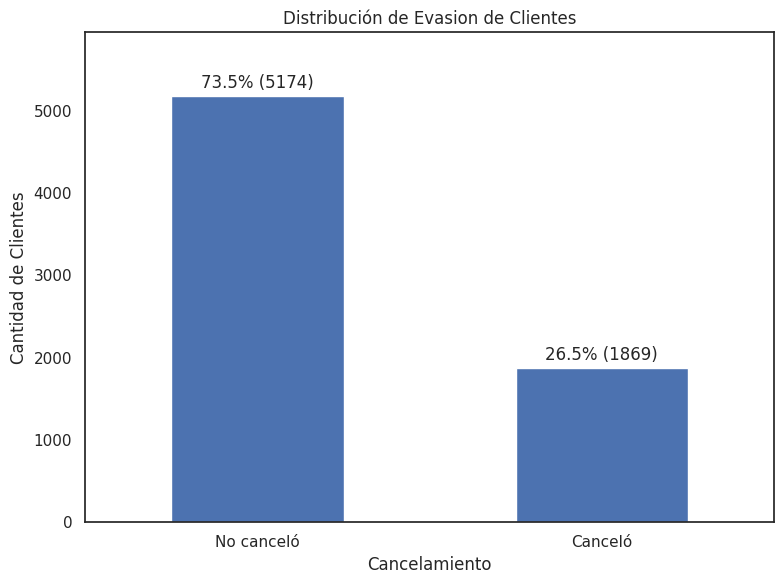

In [29]:
# Mismo cálculo de distribución de evasión que en el challenge anterior
vector_cancelacion = telecom['Cancelación (churn)'].map({
    1: 'Canceló',
    0: 'No canceló'
}).astype('string')
plt.figure(figsize=(8, 6))

ax = vector_cancelacion.value_counts().plot(kind='bar')
plt.title('Distribución de Evasion de Clientes')
plt.xlabel('Cancelamiento')
plt.ylabel('Cantidad de Clientes')
plt.xticks(rotation=0)

plt.ylim(0, vector_cancelacion.value_counts().max() * 1.15)

for i, percentage in enumerate((vector_cancelacion.value_counts() / len(vector_cancelacion)) * 100):
    ax.text(i, vector_cancelacion.value_counts().iloc[i] + 50, f'{percentage:.1f}% ({vector_cancelacion.value_counts().iloc[i]})', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Correlación y selección de variables

## Análisis de la matriz de correlación

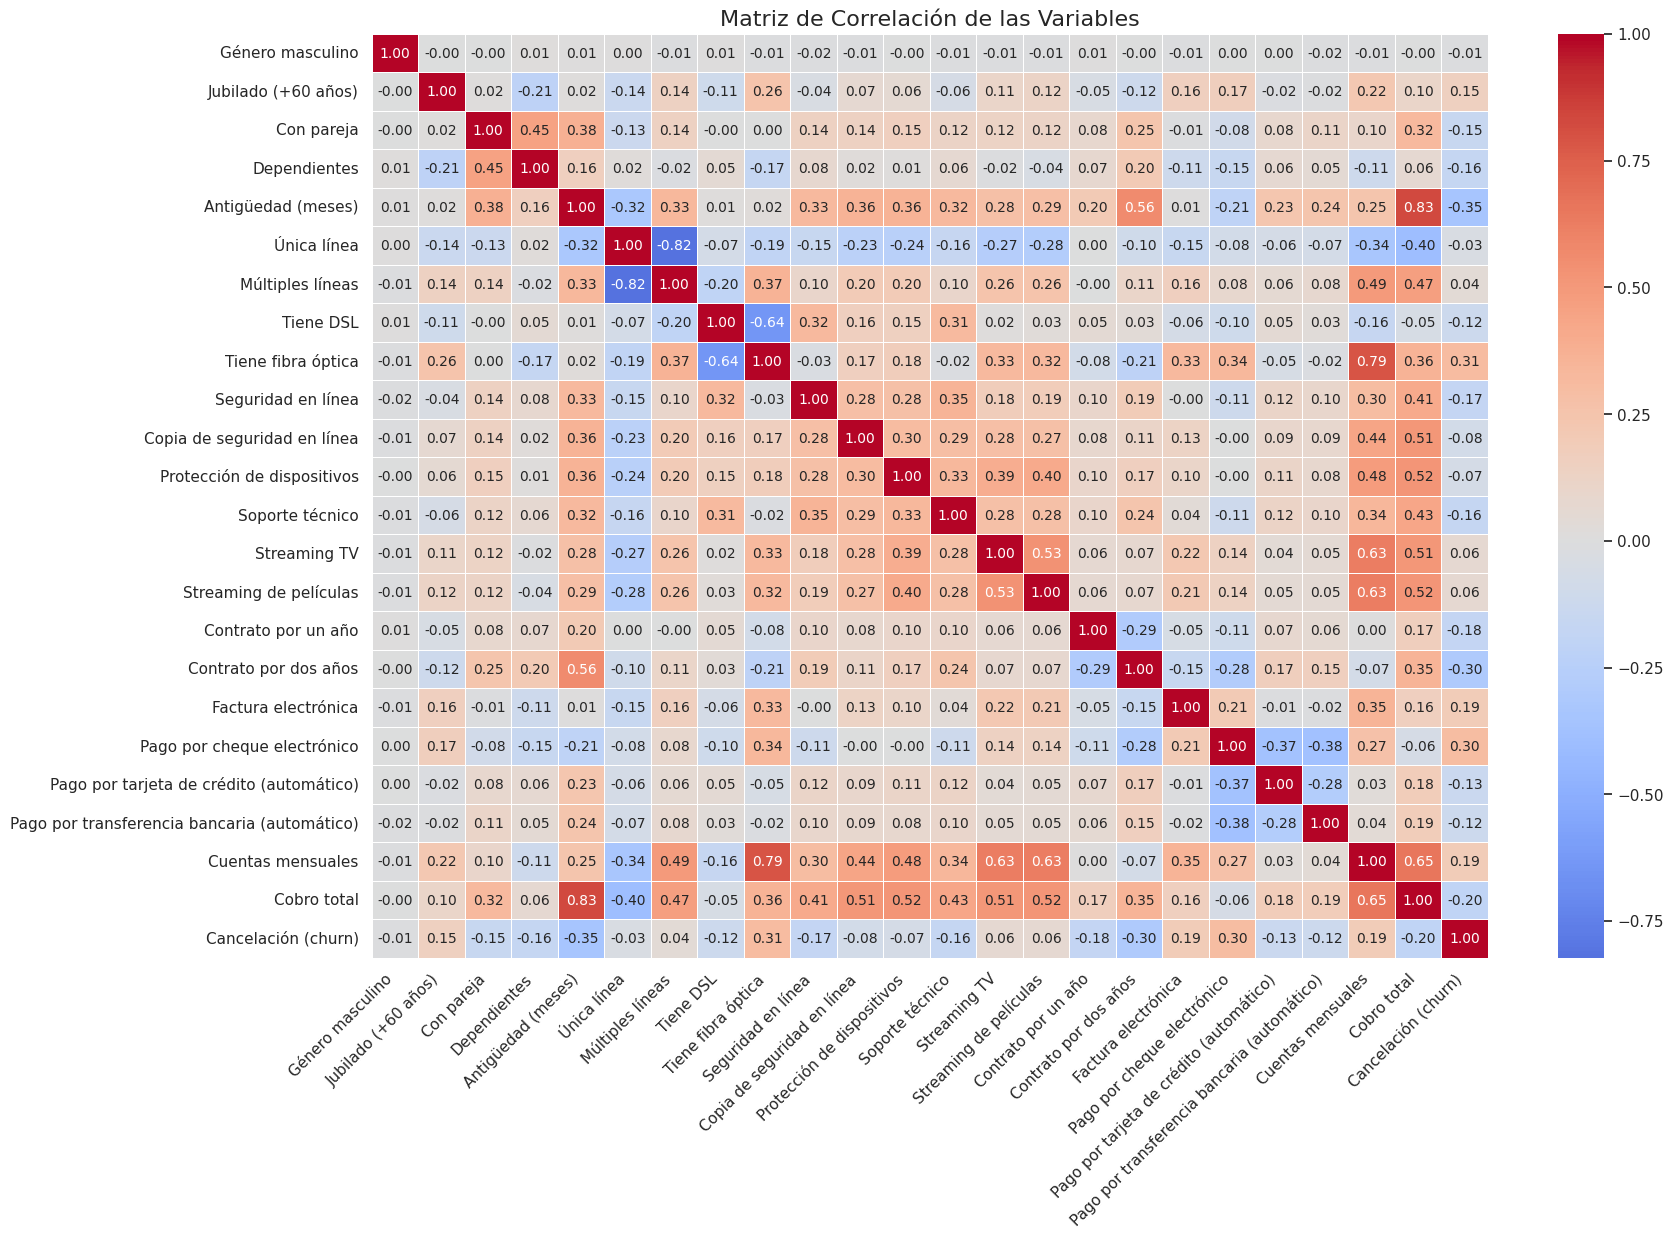

Correlación con la Cancelación (churn):
Cancelación (churn)                             1.000000
Tiene fibra óptica                              0.308020
Pago por cheque electrónico                     0.301919
Cuentas mensuales                               0.193356
Factura electrónica                             0.191825
Jubilado (+60 años)                             0.150889
Streaming TV                                    0.063228
Streaming de películas                          0.061382
Múltiples líneas                                0.040102
Género masculino                               -0.008612
Única línea                                    -0.032569
Protección de dispositivos                     -0.066160
Copia de seguridad en línea                    -0.082255
Pago por transferencia bancaria (automático)   -0.117937
Tiene DSL                                      -0.124214
Pago por tarjeta de crédito (automático)       -0.134302
Con pareja                                     -

In [30]:
# Ajustamos el estilo para que se vea mejor
sns.set_theme(style='white')

# Calculamos la matriz de correlación
corr_matrix = telecom.corr()

# Configuramos un tamaño de figura más grande para que no se vea amontonado
plt.figure(figsize=(18, 12))

# Creamos el mapa de calor con ajustes visuales mejorados
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 10} # Tamaño de la fuente de los números
)

plt.title('Matriz de Correlación de las Variables', fontsize=16)
plt.xticks(rotation=45, ha='right') # Rotamos las etiquetas del eje X
plt.show()

# Mostramos las correlaciones específicas con la variable objetivo
print('Correlación con la Cancelación (churn):')
print(corr_matrix['Cancelación (churn)'].sort_values(ascending=False))

## Análisis dirigido

Aquí observamos la relación de la cancelación del servicio con variables como el tiempo de contrato, el gasto total o los servicios elegidos, usando boxplots o diagramas de dispersión.

### Boxplots

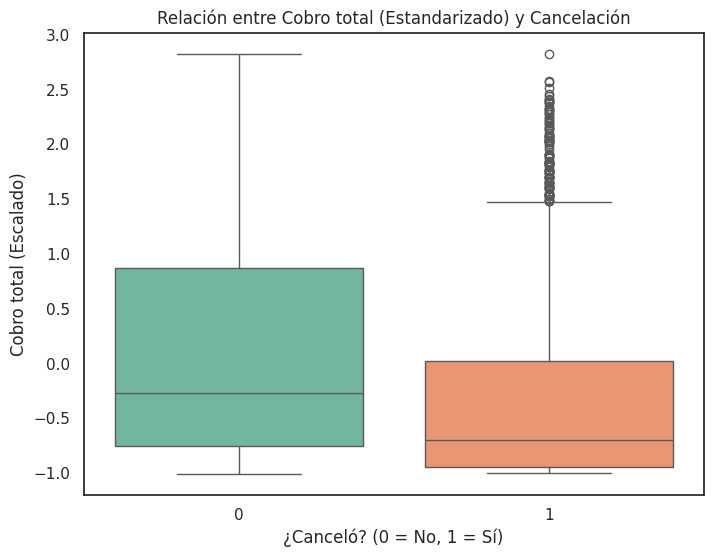

In [31]:
def boxplot_estandarizado(columna_floats):
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='Cancelación (churn)', y=columna_floats, data=telecom, palette='Set2')
    plt.title(f'Relación entre {columna_floats} (Estandarizado) y Cancelación')
    plt.xlabel('¿Canceló? (0 = No, 1 = Sí)')
    plt.ylabel(f'{columna_floats} (Escalado)')
    plt.show()

boxplot_estandarizado('Cobro total')

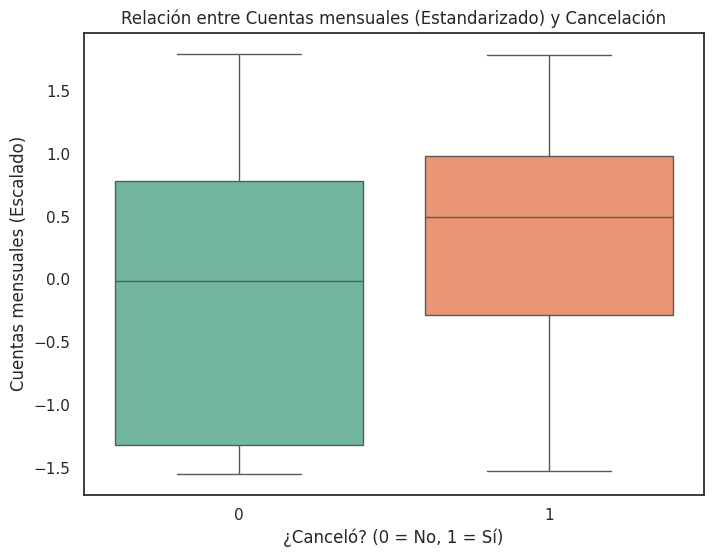

In [32]:
boxplot_estandarizado('Cuentas mensuales')

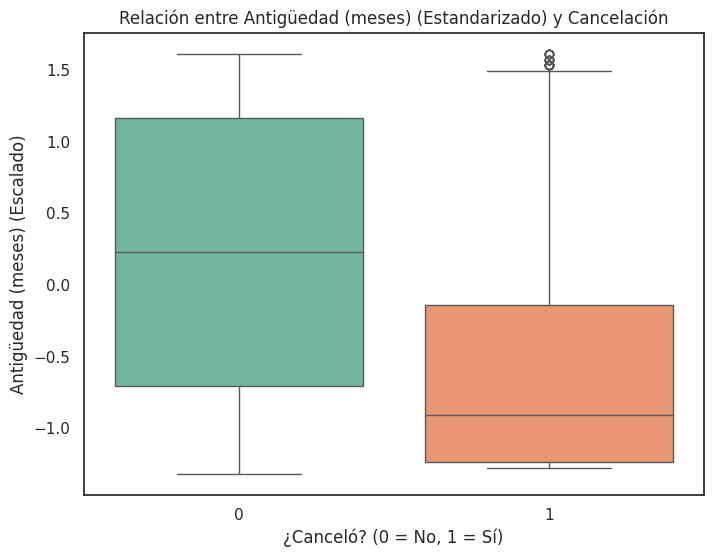

In [33]:
boxplot_estandarizado('Antigüedad (meses)')

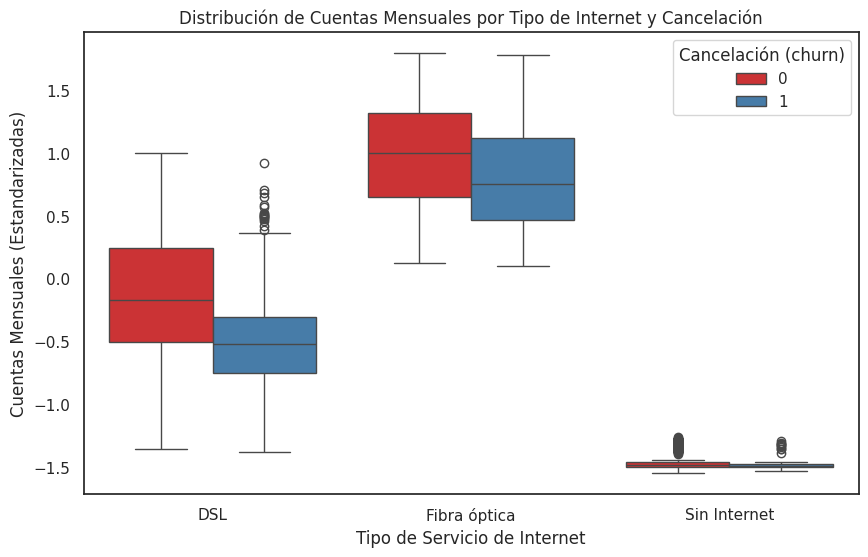

In [34]:
# Creamos una columna temporal para identificar el tipo de internet basado en las columnas One-Hot
conditions = [
    (telecom['Tiene fibra óptica'] == 1),
    (telecom['Tiene DSL'] == 1)
]
choices = ['Fibra óptica', 'DSL']
telecom['Internet_Temp'] = np.select(conditions, choices, default='Sin Internet')

# Filtramos solo por los que cancelaron (Churn = 1)
cancelados = telecom[telecom['Cancelación (churn)'] == 1]

# Creamos el boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Internet_Temp', y='Cuentas mensuales', data=telecom, hue='Cancelación (churn)', palette='Set1')

plt.title('Distribución de Cuentas Mensuales por Tipo de Internet y Cancelación')
plt.xlabel('Tipo de Servicio de Internet')
plt.ylabel('Cuentas Mensuales (Estandarizadas)')
#plt.legend(title='¿Canceló?', labels=['No', 'Sí'])

# Eliminamos la columna temporal para no ensuciar el DataFrame
telecom.drop(columns=['Internet_Temp'], inplace=True)

plt.show()

### Diagramas de dispersión (scatter plots)

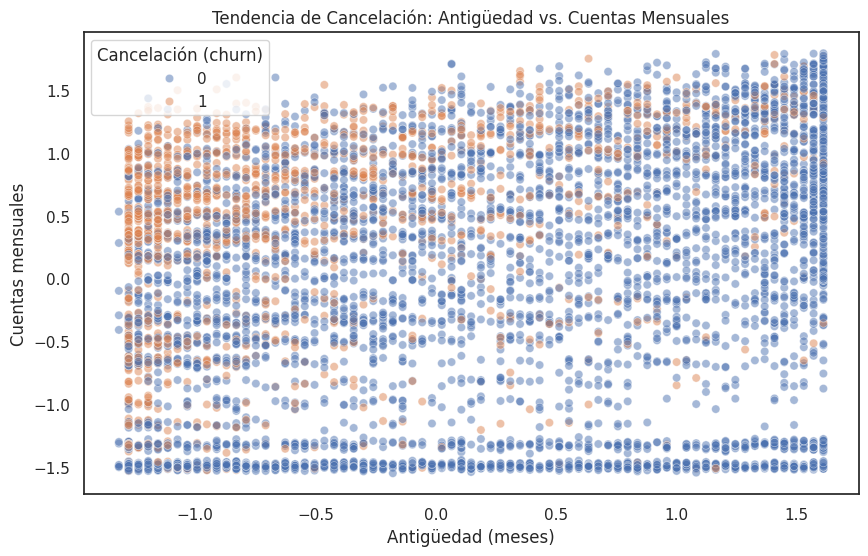

In [35]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Antigüedad (meses)', y='Cuentas mensuales',
                hue='Cancelación (churn)', data=telecom, alpha=0.5)
plt.title('Tendencia de Cancelación: Antigüedad vs. Cuentas Mensuales')
plt.show()


📈 SCATTER PLOT: Antigüedad vs Gasto Total


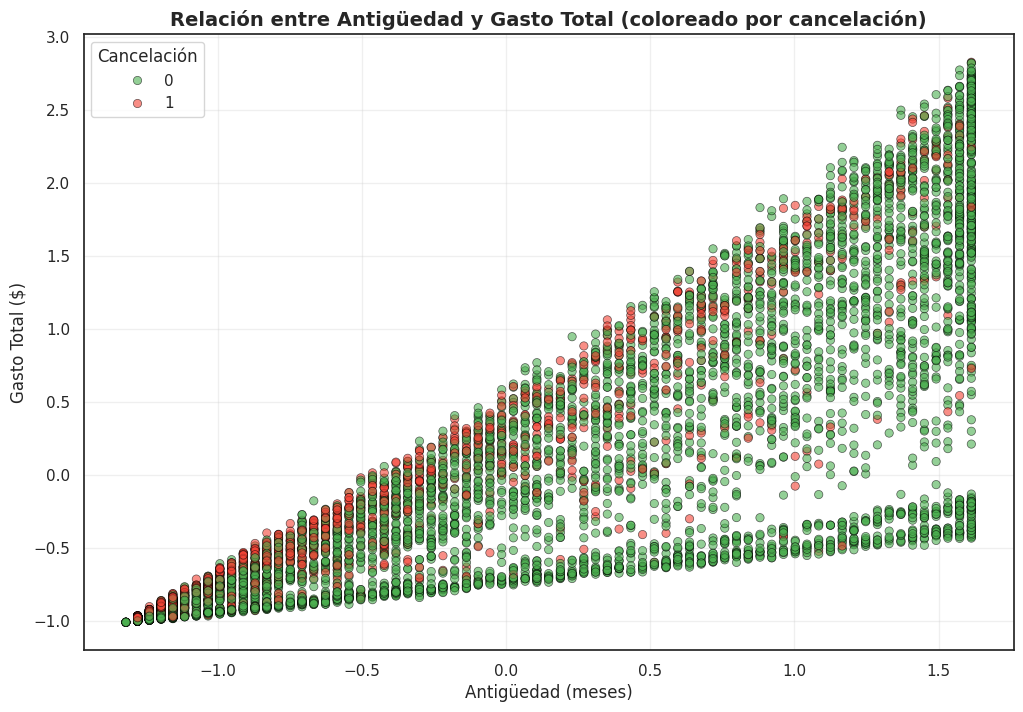

In [36]:
print("\n" + "=" * 80)
print("📈 SCATTER PLOT: Antigüedad vs Gasto Total")
print("=" * 80)

plt.figure(figsize=(12, 8))
sns.scatterplot(data=telecom, x='Antigüedad (meses)', y='Cobro total', hue='Cancelación (churn)',
                alpha=0.6, palette=['#4CAF50', '#F44336'], edgecolor='black', linewidth=0.5)
plt.title('Relación entre Antigüedad y Gasto Total (coloreado por cancelación)', fontweight='bold', fontsize=14)
plt.xlabel('Antigüedad (meses)')
plt.ylabel('Gasto Total ($)')
plt.grid(True, alpha=0.3)
plt.legend(title='Cancelación')
plt.show()

# Modelado predictivo

## Separación de datos

In [37]:
# Separamos la variable objetivo (Cancelación) del resto
X = telecom.drop(columns=['Cancelación (churn)'])
y = telecom['Cancelación (churn)']

# Creamos los conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Verificamos los tamaños
print(f"Registros totales: {len(X)}")
print(f"Registros para entrenar: {len(X_train)}")
print(f"Registros para probar: {len(X_test)}")

Registros totales: 7043
Registros para entrenar: 5634
Registros para probar: 1409


## Creación de modelos

Usaremos para ambos modelos class_weight='balanced' por el desbalance del 26.5% que encontramos (el porcentaje de clientes que cancelaron).

In [38]:
# Creamos el Modelo A (Regresión Logística)
model_log = LogisticRegression(class_weight='balanced', random_state=42)

# Creamos el Modelo B (Random Forest)
model_rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# Entrenamos ambos
model_log.fit(X_train, y_train)
model_rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

## Evaluación de los modelos

--- Evaluación: Regresión Logística ---
Exactitud: 0.74

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



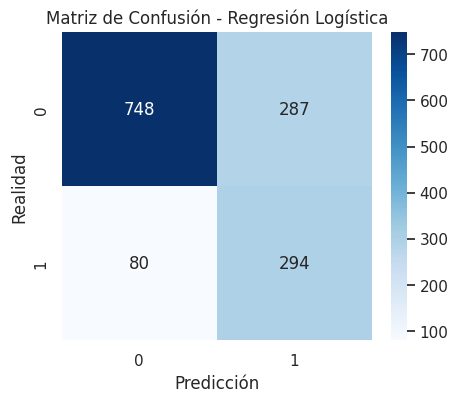

In [39]:
def evaluar_modelo(modelo, nombre, X_test, y_test):
    # Predicciones
    y_pred = modelo.predict(X_test)

    print(f"--- Evaluación: {nombre} ---")
    print(f"Exactitud: {accuracy_score(y_test, y_pred):.2f}")
    print("\nInforme de Clasificación:")
    print(classification_report(y_test, y_pred))

    # Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusión - {nombre}')
    plt.ylabel('Realidad')
    plt.xlabel('Predicción')
    plt.show()

evaluar_modelo(model_log, "Regresión Logística", X_test, y_test)

--- Evaluación: Random Forest ---
Exactitud: 0.79

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1035
           1       0.65      0.45      0.53       374

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.77      0.79      0.78      1409



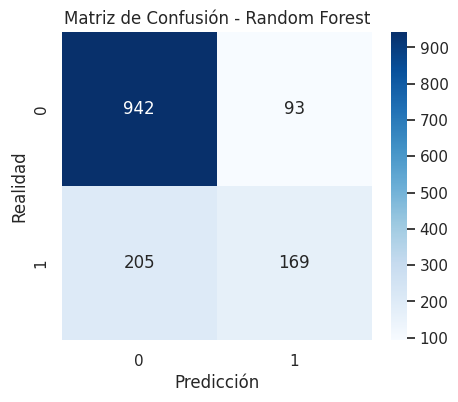

In [40]:
evaluar_modelo(model_rf, "Random Forest", X_test, y_test)

# Análisis de la importancia de las variables

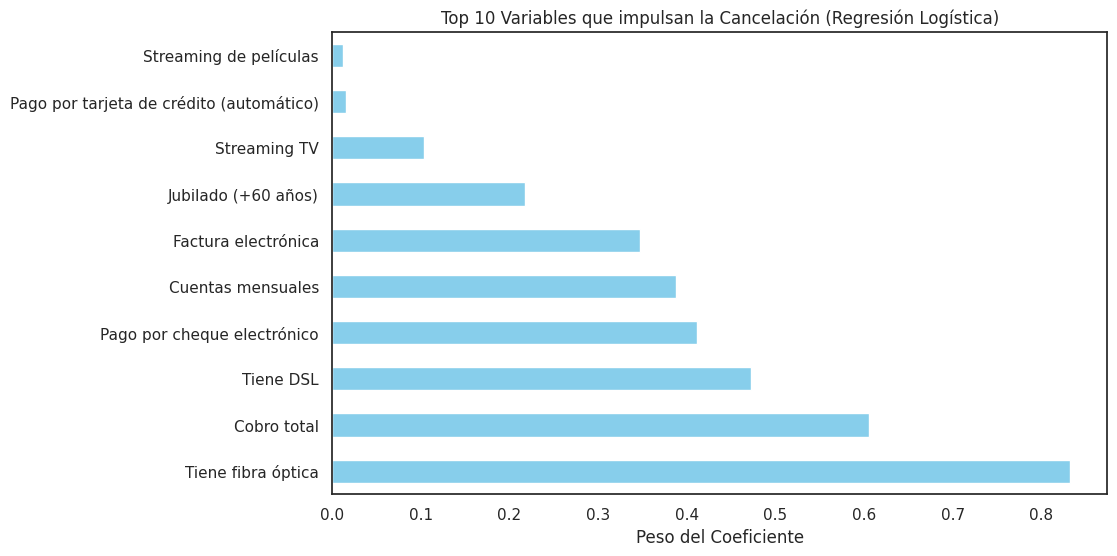

In [41]:
# Extraemos los coeficientes
importancia_log = pd.Series(model_log.coef_[0], index=X_train.columns).sort_values(ascending=False)

# Graficamos los 10 más importantes
plt.figure(figsize=(10, 6))
importancia_log.head(10).plot(kind='barh', color='skyblue')
plt.title('Top 10 Variables que impulsan la Cancelación (Regresión Logística)')
plt.xlabel('Peso del Coeficiente')
plt.show()

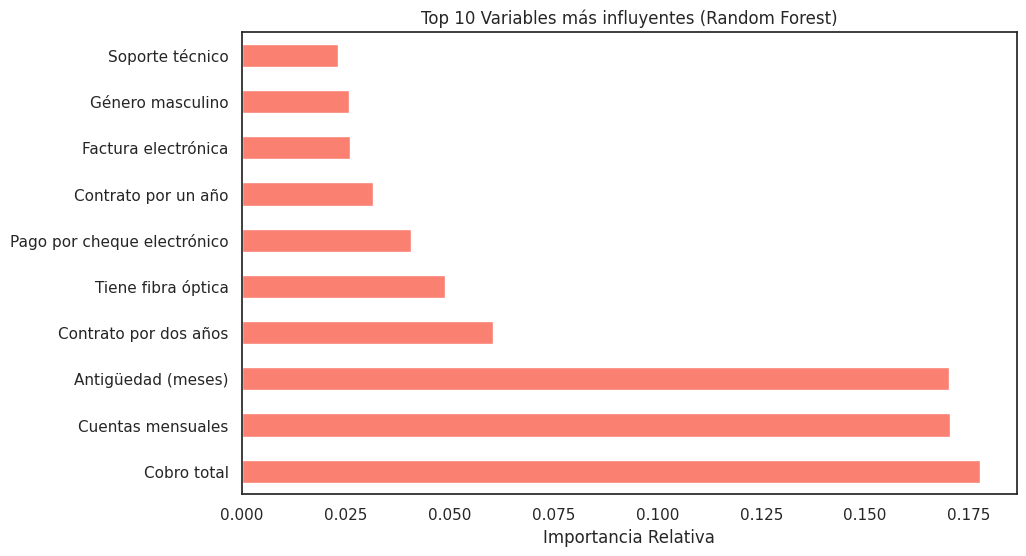

In [42]:
# Extraemos la importancia
importancia_rf = pd.Series(model_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

# Graficamos
plt.figure(figsize=(10, 6))
importancia_rf.head(10).plot(kind='barh', color='salmon')
plt.title('Top 10 Variables más influyentes (Random Forest)')
plt.xlabel('Importancia Relativa')
plt.show()

# Informe final

## Introducción

Tras realizar los análisis del challenge anterior, Telecom X LATAM me promovió a integrante del equipo de Data Science, y me asignó la nueva misión de diseñar modelos predictivos que predigan qué clientes tienen mayor probabilidad de abandonar el servicio.